# Cat Qubit Online Optimization — Version 2

This notebook implements an end-to-end online optimizer for cat qubit stabilization.

**Key improvements over version_1:**
- Probe times calibrated to `0.5 * T_baseline` for maximum sensitivity
- Reward in log-space with stable log-ratio bias proxy
- Full CMA (not SepCMA) to learn parameter correlations
- Bayesian Optimization as a second optimizer for benchmarking
- Clean separation of: baseline calibration → reward → optimizer loop → plots

## Imports

In [1]:
# Uncomment to install dependencies
!pip install "dynamiqs>=0.3.0" cmaes scipy scikit-optimize

In [2]:
import dynamiqs as dq
import jax.numpy as jnp
from jax import jit, vmap
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from cmaes import CMA          # full CMA, not SepCMA
from skopt import Optimizer as BayesOpt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## Fixed hardware parameters

These are set at fabrication and cannot be tuned online.

In [11]:
na = 15    # Hilbert space dimension for storage mode a
nb = 5     # Hilbert space dimension for buffer mode b
ka = 1.0   # kappa_a: single-photon loss rate [MHz]
kb = 10.0  # kappa_b: buffer decay rate [MHz]

# Nominal control parameters (our known starting point)
g_2_nom   = 1.0 + 0j
eps_d_nom = 4.0 + 0j

## Core simulation

Lindblad master equation solver for the storage+buffer system.
Returns ⟨sx⟩ and ⟨sz⟩ over time.

In [39]:
def make_operators():
    a = dq.tensor(dq.destroy(na), dq.eye(nb))
    b = dq.tensor(dq.eye(na), dq.destroy(nb))
    return a, b


def measure_lifetime(initial_state, tfinal, eps_d, g_2, ntimes=100):
    """
    Simulate cat qubit evolution under Lindblad master equation.
    
    Parameters
    ----------
    initial_state : str
        One of '+z', '-z', '+x', '-x', '+y', '-y'.
    tfinal : float
        Simulation end time [µs].
    eps_d : complex
        Buffer drive amplitude [MHz].
    g_2 : complex
        Two-photon coupling [MHz].
    ntimes : int
        Number of time points to save.
        
    Returns
    -------
    dynamiqs result with expects[0]=<sx>, expects[1]=<sz>
    """
    a, b = make_operators()
    
    eps_2   = 2 * g_2 * eps_d / kb
    kappa_2 = 4 * jnp.abs(g_2)**2 / kb
    cat_arg = 2 / kappa_2 * (eps_2 - ka / 4)
    
    # Check 1: cat_arg must be positive
    if float(cat_arg.real) <= 0:
        raise ValueError(
            f"Unphysical parameters: cat_arg={float(cat_arg.real):.4f}. "
            f"Single photon loss too strong relative to two-photon drive."
        )
    
    alpha = jnp.sqrt(cat_arg)
    
    # Check 2: alpha must be large enough for logical basis to be valid
    # For alpha < 1, |+alpha> and |-alpha> overlap significantly:
    # <alpha|-alpha> = exp(-2*alpha^2) > exp(-2) ~ 0.13
    # making the cat logical basis ill-defined
    if float(alpha.real) < 1.0:
        raise ValueError(
            f"Cat too small: alpha={float(alpha.real):.3f} < 1.0. "
            f"Logical basis is ill-defined since |<alpha|-alpha>| = "
            f"{float(jnp.exp(-2*alpha.real**2)):.3f} >> 0."
        )
    
    H = (jnp.conj(g_2) * a @ a @ b.dag()
         + g_2 * a.dag() @ a.dag() @ b
         - eps_d * b.dag()
         - jnp.conj(eps_d) * b)
    
    loss_b = jnp.sqrt(kb) * b
    loss_a = jnp.sqrt(ka) * a
    
    tsave = jnp.linspace(0, tfinal, ntimes)
    
    g_state = dq.coherent(na, alpha)
    e_state = dq.coherent(na, -alpha)
    
    basis = {
        '+z': g_state,
        '-z': e_state,
        '+x': (g_state + e_state) / jnp.sqrt(2),
        '-x': (g_state - e_state) / jnp.sqrt(2),
        '+y': (g_state + 1j * e_state) / jnp.sqrt(2),
        '-y': (g_state - 1j * e_state) / jnp.sqrt(2),
    }
    
    # sx = photon parity = exp(i*pi*n): experimentally accessible without knowing alpha
    sx = (1j * jnp.pi * a.dag() @ a).expm()
    
    # sz = projector difference: requires knowing alpha
    sz = g_state @ g_state.dag() - e_state @ e_state.dag()
    sz = dq.tensor(sz, dq.eye(nb))
    
    psi0 = dq.tensor(basis[initial_state], dq.fock(nb, 0))
    
    res = dq.mesolve(
        H, [loss_b, loss_a], psi0, tsave,
        options=dq.Options(progress_meter=False),
        exp_ops=[sx, sz]
    )
    return res

## Exponential fit utility

In [40]:
def exp_model(p, t):
    A, tau, C = p
    return A * np.exp(-t / tau) + C


def robust_exp_fit(t, y):
    """
    Fit y = A * exp(-t/tau) + C using robust soft_l1 loss.
    Returns dict with 'tau' and 'y_fit'.
    """
    t = np.array(t)
    y = np.array(y)

    A0   = float(y.max() - y.min())
    C0   = float(y.min())
    tau0 = float(t.max() - t.min())

    res = least_squares(
        lambda p: exp_model(p, t) - y,
        [A0, tau0, C0],
        bounds=([0, 1e-6, -np.inf], [np.inf, np.inf, np.inf]),
        loss='soft_l1',
        f_scale=0.1
    )
    tau = res.x[1]
    return {'tau': tau, 'y_fit': exp_model(res.x, t)}

## Step 1: Baseline calibration (run once offline)

This is the one time we run full exponential fits to establish:
- True `Tx_baseline` and `Tz_baseline` at nominal parameters
- Probe times = `0.5 * T_baseline` (maximum sensitivity point on the decay curve)
- Reference proxy values `sx_nom` and `sz_nom` at those probe times

Running baseline calibration (full exponential fits)...
  Tx  = 0.1700 µs
  Tz  = 57.19 µs
  η   = 336.4
  T_probe_x = 0.0850 µs
  T_probe_z = 28.59 µs
  sx_nom = 0.6436  (expected ≈ exp(-0.5) ≈ 0.607)
  sz_nom = 0.5983  (expected ≈ exp(-0.5) ≈ 0.607)


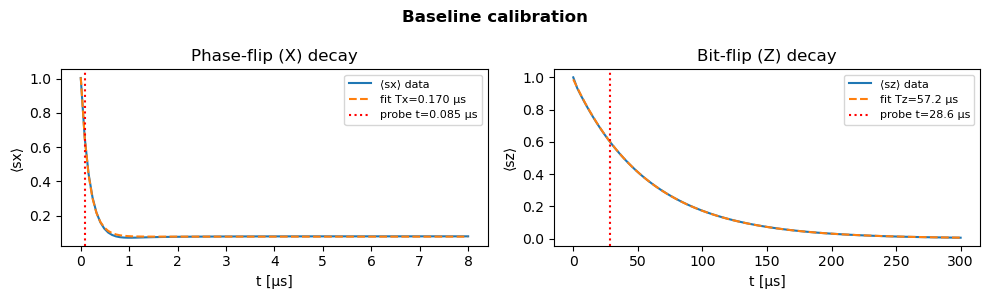

In [41]:
def compute_baseline(g_2, eps_d, verbose=True):
    """
    Run full exponential fits at nominal parameters to establish:
    - Tx_baseline, Tz_baseline, eta_baseline
    - Optimal probe times (0.5 * T_baseline)
    - Reference proxy values at those probe times

    This is the only time we run expensive full fits.
    Everything downstream uses single-timepoint proxies.
    """
    if verbose:
        print("Running baseline calibration (full exponential fits)...")

    # ---- Tx: phase-flip lifetime (short, O(1 µs)) ----
    tfinal_x = 8.0   # long enough to see the full Tx decay
    res_x = measure_lifetime('+x', tfinal_x, eps_d, g_2, ntimes=100)
    ts_x  = np.linspace(0, tfinal_x, 100)
    fit_x = robust_exp_fit(ts_x, res_x.expects[0].real)
    Tx    = fit_x['tau']

    # ---- Tz: bit-flip lifetime (long, O(100 µs)) ----
    tfinal_z = 300.0  # long enough to see the start of Tz decay
    res_z = measure_lifetime('+z', tfinal_z, eps_d, g_2, ntimes=100)
    ts_z  = np.linspace(0, tfinal_z, 100)
    fit_z = robust_exp_fit(ts_z, res_z.expects[1].real)
    Tz    = fit_z['tau']

    eta = Tz / Tx

    if verbose:
        print(f"  Tx  = {Tx:.4f} µs")
        print(f"  Tz  = {Tz:.2f} µs")
        print(f"  η   = {eta:.1f}")

    # ---- Probe times: 0.5 * T is the point of maximum slope ----
    # At t = 0.5*tau, exp(-t/tau) = exp(-0.5) ≈ 0.6, slope = -1/tau * exp(-0.5)
    # This maximises |d(signal)/d(tau)|, so small changes in lifetime
    # produce the largest observable change in the proxy.
    T_probe_x = 0.5 * Tx
    T_probe_z = 0.5 * Tz

    if verbose:
        print(f"  T_probe_x = {T_probe_x:.4f} µs")
        print(f"  T_probe_z = {T_probe_z:.2f} µs")

    # ---- Reference proxy values at nominal parameters ----
    res_xp = measure_lifetime('+x', T_probe_x, eps_d, g_2, ntimes=5)
    res_zp = measure_lifetime('+z', T_probe_z, eps_d, g_2, ntimes=5)
    sx_nom = float(res_xp.expects[0].real[-1])
    sz_nom = float(res_zp.expects[1].real[-1])

    if verbose:
        print(f"  sx_nom = {sx_nom:.4f}  (expected ≈ exp(-0.5) ≈ 0.607)")
        print(f"  sz_nom = {sz_nom:.4f}  (expected ≈ exp(-0.5) ≈ 0.607)")

    # ---- Plot fits for verification ----
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    axes[0].plot(ts_x, res_x.expects[0].real, label='⟨sx⟩ data')
    axes[0].plot(ts_x, fit_x['y_fit'], '--', label=f'fit Tx={Tx:.3f} µs')
    axes[0].axvline(T_probe_x, color='red', linestyle=':', label=f'probe t={T_probe_x:.3f} µs')
    axes[0].set(xlabel='t [µs]', ylabel='⟨sx⟩', title='Phase-flip (X) decay')
    axes[0].legend(fontsize=8)

    axes[1].plot(ts_z, res_z.expects[1].real, label='⟨sz⟩ data')
    axes[1].plot(ts_z, fit_z['y_fit'], '--', label=f'fit Tz={Tz:.1f} µs')
    axes[1].axvline(T_probe_z, color='red', linestyle=':', label=f'probe t={T_probe_z:.1f} µs')
    axes[1].set(xlabel='t [µs]', ylabel='⟨sz⟩', title='Bit-flip (Z) decay')
    axes[1].legend(fontsize=8)

    plt.suptitle('Baseline calibration', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return dict(
        Tx=Tx, Tz=Tz, eta=eta,
        T_probe_x=T_probe_x, T_probe_z=T_probe_z,
        sx_nom=sx_nom, sz_nom=sz_nom
    )


baseline = compute_baseline(g_2_nom, eps_d_nom)

# Unpack for convenience
Tx_baseline = baseline['Tx']
Tz_baseline = baseline['Tz']
eta_baseline = baseline['eta']
T_PROBE_X   = baseline['T_probe_x']
T_PROBE_Z   = baseline['T_probe_z']
sx_nom      = baseline['sx_nom']
sz_nom      = baseline['sz_nom']

# Log-space reference for bias proxy
# log(sz_nom) - log(sx_nom) ≈ log(Tz/Tx) (up to a constant from probe times)
# We use this difference as our target in the reward
LOG_BIAS_TARGET = float(np.log(sz_nom + 1e-9) - np.log(sx_nom + 1e-9))

## Step 2: Reward function

**Design:**
- Two short simulations per evaluation (one for sx, one for sz)
- Log-space rewards: `log(sx)` and `log(sz)` are linear in `-1/Tx` and `-1/Tz`
- Bias penalty in log-ratio space: `(log(sz) - log(sx) - LOG_BIAS_TARGET)²`
  This is a clean proxy for `(log(Tz/Tx) - log(η_target))²`
  and avoids the instability of the raw ratio `sz/sx`

**Why log space?**
- `sx_proxy ≈ exp(-T_PROBE_X / Tx)` so `log(sx) = -T_PROBE_X / Tx`
- Maximising `log(sx)` ≡ minimising `1/Tx` ≡ maximising `Tx` ✓
- The ratio `log(sz) - log(sx) = -T_PROBE_Z/Tz + T_PROBE_X/Tx` tracks the bias
  monotonically when probe times are well-calibrated

In [42]:
def reward(g2, eps_d, w_lifetime=1.0, w_bias=2.0, eps=1e-9):
    """
    Proxy-based reward for cat qubit optimization.

    Cost: 2 short simulations (ntimes=5 each).

    Parameters
    ----------
    g2 : complex
        Two-photon coupling.
    eps_d : complex
        Buffer drive amplitude.
    w_lifetime : float
        Weight on lifetime maximization term.
    w_bias : float
        Weight on bias-targeting penalty.
    eps : float
        Small constant for numerical stability in log.

    Returns
    -------
    r : float
        Scalar reward (higher = better).
    sx : float
        ⟨sx⟩ proxy at T_PROBE_X.
    sz : float
        ⟨sz⟩ proxy at T_PROBE_Z.
    log_bias : float
        log(sz) - log(sx): current log-ratio proxy.
    """
    # ---- sx proxy: sensitive to Tx ----
    res_x = measure_lifetime('+x', T_PROBE_X, eps_d, g2, ntimes=5)
    sx = float(res_x.expects[0].real[-1])

    # ---- sz proxy: sensitive to Tz ----
    res_z = measure_lifetime('+z', T_PROBE_Z, eps_d, g2, ntimes=5)
    sz = float(res_z.expects[1].real[-1])

    # ---- Log-space lifetime reward ----
    log_sx = np.log(max(sx, eps))
    log_sz = np.log(max(sz, eps))
    r_lifetime = log_sx + log_sz

    # ---- Log-ratio bias penalty ----
    # log(sz) - log(sx) tracks log(Tz/Tx) monotonically
    # We penalise deviation from the baseline log-ratio
    log_bias = log_sz - log_sx
    r_bias = -w_bias * (log_bias - LOG_BIAS_TARGET) ** 2

    r = w_lifetime * r_lifetime + r_bias
    return r, sx, sz, log_bias


# ---- Sanity check: nominal should score near 2 * log(exp(-0.5)) = -1 ----
r_nom, sx_check, sz_check, lb_check = reward(g_2_nom, eps_d_nom)
print(f"Nominal reward:    {r_nom:.4f}")
print(f"sx_proxy:          {sx_check:.4f}  (should ≈ {sx_nom:.4f})")
print(f"sz_proxy:          {sz_check:.4f}  (should ≈ {sz_nom:.4f})")
print(f"log_bias:          {lb_check:.4f}  (target = {LOG_BIAS_TARGET:.4f})")
print()

# ---- Sanity check: a perturbed point should score lower ----
r_perturbed, _, _, _ = reward(g_2_nom * 0.5, eps_d_nom)
print(f"Perturbed reward:  {r_perturbed:.4f}  (should be < {r_nom:.4f})")
assert r_perturbed < r_nom, "Reward not sensitive to parameter changes!"

Nominal reward:    -0.9542
sx_proxy:          0.6436  (should ≈ 0.6436)
sz_proxy:          0.5983  (should ≈ 0.5983)
log_bias:          -0.0729  (target = -0.0729)

Perturbed reward:  -1.6587  (should be < -0.9542)


## Step 3a: Optimizer 1 — CMA-ES

We use full `CMA` (not `SepCMA`) to learn correlations between the
four knobs: Re(g2), Im(g2), Re(eps_d), Im(eps_d).

In [43]:
def run_cmaes(n_epochs=8, batch_size=8, sigma0=0.2, seed=0, verbose=True):
    """
    Run CMA-ES optimization of the cat qubit reward.

    Returns
    -------
    history : dict with keys 'rewards', 'sx', 'sz', 'params', 'best_params'
    """
    BOUNDS = np.array([
        [0.1,  8.0],   # Re(g2)
        [-1.0, 2.0],   # Im(g2)
        [1.0,  15.0],   # Re(eps_d)
        [-1.0, 2.0],   # Im(eps_d)
    ])

    mean0 = np.array([
        float(g_2_nom.real),
        float(g_2_nom.imag),
        float(eps_d_nom.real),
        float(eps_d_nom.imag),
    ])

    optimizer = CMA(
        mean=mean0,
        sigma=sigma0,
        bounds=BOUNDS,
        population_size=batch_size,
        seed=seed,
    )

    history = {
        'rewards': [], 'rewards_std': [],
        'sx': [], 'sz': [],
        'params': [],
    }

    best_reward = -np.inf
    best_params = mean0.copy()

    for epoch in range(n_epochs):
        xs = np.array([optimizer.ask() for _ in range(optimizer.population_size)])

        rewards, sxs, szs = [], [], []
        for x in xs:
            g2    = complex(x[0], x[1])
            eps_d = complex(x[2], x[3])

            # Check validity before simulating
            eps_2   = 2 * g2 * eps_d / kb
            kappa_2 = 4 * abs(g2)**2 / kb
            cat_arg = 2 / kappa_2 * (eps_2 - ka / 4)

            if float(np.real(cat_arg)) <= 0:
                rewards.append(-50.0)
                sxs.append(0.0)
                szs.append(0.0)
            else:
                try:
                    r, sx, sz, _ = reward(g2, eps_d)
                    rewards.append(r)
                    sxs.append(sx)
                    szs.append(sz)
                except Exception:
                    rewards.append(-50.0)
                    sxs.append(0.0)
                    szs.append(0.0)

        # CMA-ES minimises: pass negative reward
        solutions = [(xs[j], -rewards[j]) for j in range(len(xs))]
        optimizer.tell(solutions)

        mean_r = float(np.mean(rewards))
        if mean_r > best_reward:
            best_reward = mean_r
            best_params = optimizer.mean.copy()

        history['rewards'].append(mean_r)
        history['rewards_std'].append(float(np.std(rewards)))
        history['sx'].append(float(np.mean(sxs)))
        history['sz'].append(float(np.mean(szs)))
        history['params'].append(optimizer.mean.copy())

        if verbose and epoch % 5 == 0:
            m = optimizer.mean
            print(f"Epoch {epoch:3d} | "
                  f"g2={m[0]:.3f}+{m[1]:.3f}j | "
                  f"eps_d={m[2]:.3f}+{m[3]:.3f}j | "
                  f"reward={mean_r:.3f}")

    history['best_params'] = best_params
    for k in ['rewards', 'rewards_std', 'sx', 'sz', 'params']:
        history[k] = np.array(history[k])

    return history


#print("=" * 60)
print("Running CMA-ES...")
#print("=" * 60)
history_cma = run_cmaes(n_epochs=60, batch_size=8)

Running CMA-ES...
Epoch   0 | g2=1.315+-0.007j | eps_d=4.172+0.250j | reward=-1.030
Epoch   5 | g2=1.822+-0.206j | eps_d=4.960+0.955j | reward=-0.860
Epoch  10 | g2=2.379+-0.758j | eps_d=5.957+0.884j | reward=-0.775
Epoch  15 | g2=3.196+-0.095j | eps_d=6.807+1.459j | reward=-0.667
Epoch  20 | g2=4.032+-0.100j | eps_d=8.360+0.237j | reward=-0.627
Epoch  25 | g2=7.115+-0.106j | eps_d=13.417+1.165j | reward=-0.574
Epoch  30 | g2=7.403+0.128j | eps_d=14.176+1.207j | reward=-0.565
Epoch  35 | g2=7.639+0.216j | eps_d=14.589+0.625j | reward=-0.563
Epoch  40 | g2=7.557+0.106j | eps_d=14.508+0.491j | reward=-0.562
Epoch  45 | g2=7.663+-0.053j | eps_d=14.728+-0.067j | reward=-0.562
Epoch  50 | g2=7.725+0.084j | eps_d=14.834+-0.033j | reward=-0.561
Epoch  55 | g2=7.676+0.026j | eps_d=14.753+0.114j | reward=-0.561


## Step 3b: Optimizer 2 — Bayesian Optimization

Gaussian Process surrogate with Expected Improvement acquisition.
Well-suited for low-dimensional, expensive-to-evaluate problems.
We use sequential (batch_size=1) acquisition here for comparison.

In [10]:
def run_bayes_opt(n_epochs=120, seed=0, verbose=True):
    """
    Run Bayesian Optimization of the cat qubit reward.

    Uses a Gaussian Process surrogate with Expected Improvement.
    Sequential (one point per epoch) — each epoch costs 1 simulation.

    Returns
    -------
    history : dict with keys 'rewards', 'sx', 'sz', 'params', 'best_params'
    """
    DIMENSIONS = [
        (0.1,  3.0),   # Re(g2)
        (-1.0, 1.0),   # Im(g2)
        (1.0,  8.0),   # Re(eps_d)
        (-1.0, 1.0),   # Im(eps_d)
    ]

    optimizer = BayesOpt(
        dimensions=DIMENSIONS,
        base_estimator='GP',
        acq_func='EI',         # Expected Improvement
        acq_optimizer='lbfgs',
        random_state=seed,
        n_initial_points=8,    # random exploration before GP kicks in
    )

    history = {
        'rewards': [], 'sx': [], 'sz': [], 'params': []
    }

    best_reward = -np.inf
    best_params = None

    for epoch in range(n_epochs):
        x = optimizer.ask()

        g2    = complex(x[0], x[1])
        eps_d = complex(x[2], x[3])

        eps_2   = 2 * g2 * eps_d / kb
        kappa_2 = 4 * abs(g2)**2 / kb
        cat_arg = 2 / kappa_2 * (eps_2 - ka / 4)

        if float(np.real(cat_arg)) <= 0:
            r, sx, sz = -50.0, 0.0, 0.0
        else:
            try:
                r, sx, sz, _ = reward(g2, eps_d)
            except Exception:
                r, sx, sz = -50.0, 0.0, 0.0

        # skopt minimises: pass negative reward
        optimizer.tell(x, -r)

        if r > best_reward:
            best_reward = r
            best_params = np.array(x)

        history['rewards'].append(r)
        history['sx'].append(sx)
        history['sz'].append(sz)
        history['params'].append(np.array(x))

        if verbose and epoch % 5 == 0:
            print(f"Epoch {epoch:3d} | "
                  f"g2={x[0]:.3f}+{x[1]:.3f}j | "
                  f"eps_d={x[2]:.3f}+{x[3]:.3f}j | "
                  f"reward={r:.3f}")

    history['best_params'] = best_params
    for k in ['rewards', 'sx', 'sz', 'params']:
        history[k] = np.array(history[k])

    return history


#print("=" * 60)
print("Running Bayesian Optimization...")
#print("=" * 60)
history_bo = run_bayes_opt(n_epochs=20)

Running Bayesian Optimization...


ERROR:2026-05-09 22:06:10,705:jax._src.callback:95: jax.pure_callback failed
Traceback (most recent call last):
  File "/Users/danielgarciagonzalez/miniconda3/envs/research/lib/python3.11/site-packages/jax/_src/callback.py", line 93, in pure_callback_impl
    return tree_util.tree_map(np.asarray, callback(*args))
                                          ^^^^^^^^^^^^^^^
  File "/Users/danielgarciagonzalez/miniconda3/envs/research/lib/python3.11/site-packages/jax/_src/callback.py", line 71, in __call__
    return tree_util.tree_leaves(self.callback_func(*args, **kwargs))
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/danielgarciagonzalez/miniconda3/envs/research/lib/python3.11/site-packages/equinox/_errors.py", line 88, in raises
    raise _EquinoxRuntimeError(
equinox._errors._EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.


--------------------
An error occurred during the runtime of your JAX progra

Epoch   0 | g2=1.819+0.689j | eps_d=7.006+0.695j | reward=-50.000
Epoch   5 | g2=1.473+0.602j | eps_d=4.643+0.358j | reward=-0.959


ERROR:2026-05-09 22:07:45,399:jax._src.callback:95: jax.pure_callback failed
Traceback (most recent call last):
  File "/Users/danielgarciagonzalez/miniconda3/envs/research/lib/python3.11/site-packages/jax/_src/callback.py", line 93, in pure_callback_impl
    return tree_util.tree_map(np.asarray, callback(*args))
                                          ^^^^^^^^^^^^^^^
  File "/Users/danielgarciagonzalez/miniconda3/envs/research/lib/python3.11/site-packages/jax/_src/callback.py", line 71, in __call__
    return tree_util.tree_leaves(self.callback_func(*args, **kwargs))
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/danielgarciagonzalez/miniconda3/envs/research/lib/python3.11/site-packages/equinox/_errors.py", line 88, in raises
    raise _EquinoxRuntimeError(
equinox._errors._EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.


--------------------
An error occurred during the runtime of your JAX progra

Epoch  10 | g2=0.100+0.575j | eps_d=6.995+-0.661j | reward=-746.316


ERROR:2026-05-09 22:08:34,236:jax._src.callback:95: jax.pure_callback failed
Traceback (most recent call last):
  File "/Users/danielgarciagonzalez/miniconda3/envs/research/lib/python3.11/site-packages/jax/_src/callback.py", line 93, in pure_callback_impl
    return tree_util.tree_map(np.asarray, callback(*args))
                                          ^^^^^^^^^^^^^^^
  File "/Users/danielgarciagonzalez/miniconda3/envs/research/lib/python3.11/site-packages/jax/_src/callback.py", line 71, in __call__
    return tree_util.tree_leaves(self.callback_func(*args, **kwargs))
                                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/danielgarciagonzalez/miniconda3/envs/research/lib/python3.11/site-packages/equinox/_errors.py", line 88, in raises
    raise _EquinoxRuntimeError(
equinox._errors._EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.


--------------------
An error occurred during the runtime of your JAX progra

Epoch  15 | g2=0.100+1.000j | eps_d=8.000+-1.000j | reward=-803.116


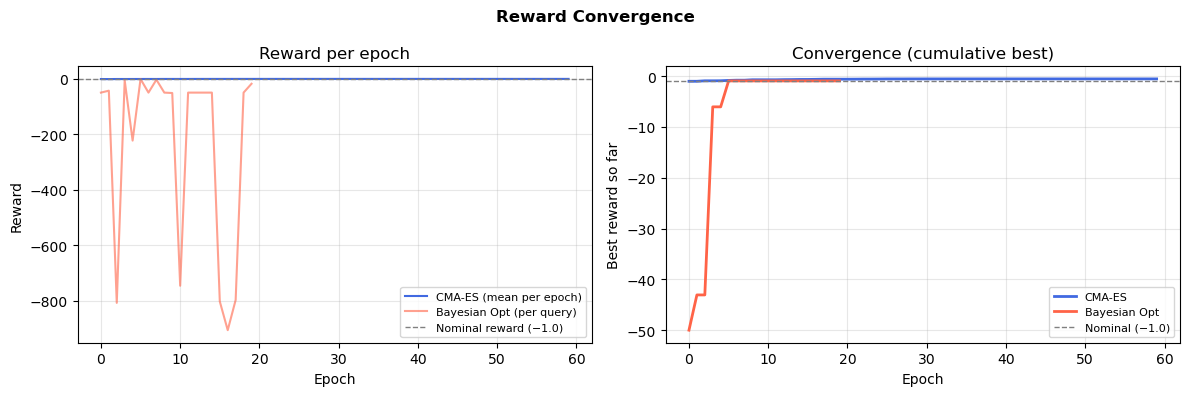

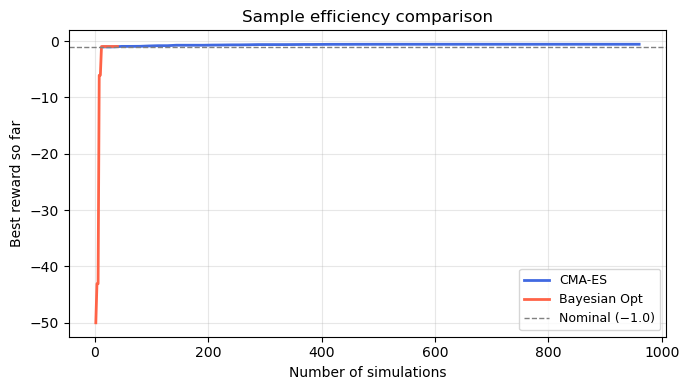

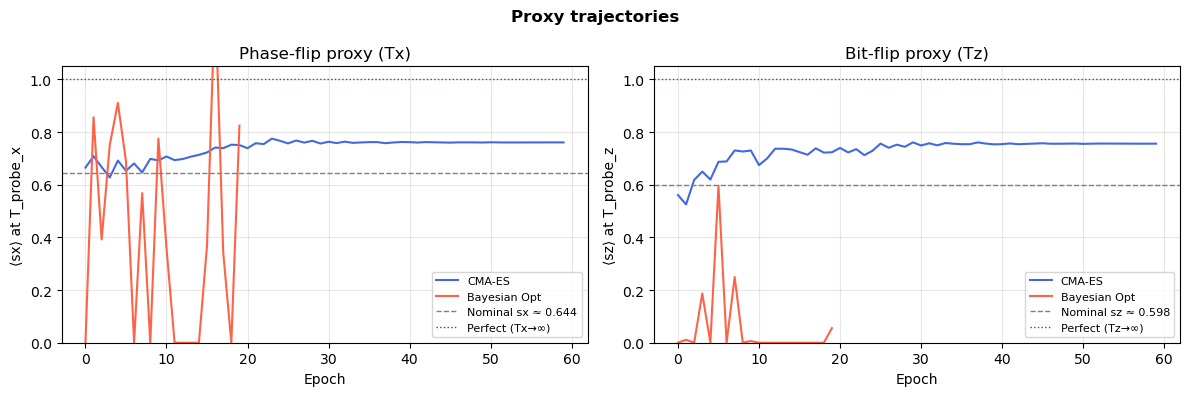

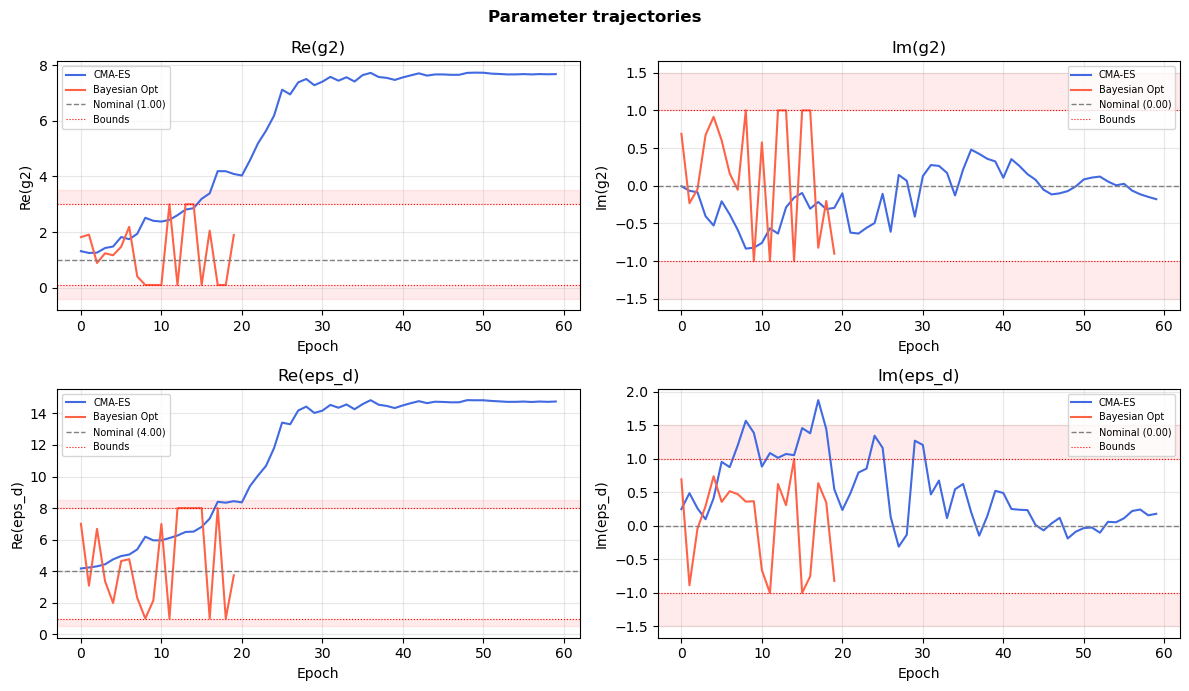

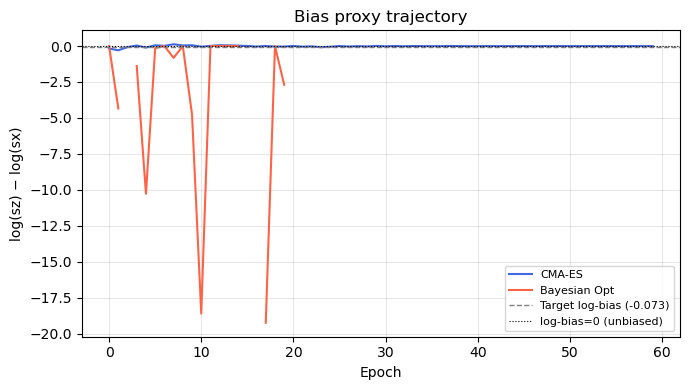

Parameter          Nominal     CMA-ES  Bayes Opt
------------------------------------------------------------
Re(g2)              1.0000     7.6752     1.4735
Im(g2)              0.0000    -0.1776     0.6018
Re(eps_d)           4.0000    14.7555     4.6433
Im(eps_d)           0.0000     0.1801     0.3578
------------------------------------------------------------
Best reward        -1.0000    -0.5615    -0.9587


In [24]:
import numpy as np
import matplotlib.pyplot as plt

eps = 1e-9
BATCH_SIZE = 8  # adjust to match what you used

epochs_cma = np.arange(len(history_cma['rewards']))
epochs_bo  = np.arange(len(history_bo['rewards']))

params_cma = np.array(history_cma['params'])
params_bo  = np.array(history_bo['params'])

log_bias_cma = np.log(history_cma['sz'] + eps) - np.log(history_cma['sx'] + eps)
log_bias_bo  = np.log(history_bo['sz']  + eps) - np.log(history_bo['sx']  + eps)

labels   = ['Re(g2)', 'Im(g2)', 'Re(eps_d)', 'Im(eps_d)']
nominals = [float(g_2_nom.real), float(g_2_nom.imag),
            float(eps_d_nom.real), float(eps_d_nom.imag)]
bounds_lo = [0.1, -1.0, 1.0, -1.0]
bounds_hi = [3.0,  1.0, 8.0,  1.0]  # adjust if you widened bounds

# ── 1. Reward convergence ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(epochs_cma, history_cma['rewards'], color='royalblue', label='CMA-ES (mean per epoch)')
ax.fill_between(epochs_cma,
    history_cma['rewards'] - history_cma['rewards_std'],
    history_cma['rewards'] + history_cma['rewards_std'],
    alpha=0.15, color='royalblue')
ax.plot(epochs_bo, history_bo['rewards'], color='tomato', alpha=0.6, label='Bayesian Opt (per query)')
ax.axhline(-1.0, linestyle='--', color='gray', linewidth=1, label='Nominal reward (−1.0)')
ax.set(xlabel='Epoch', ylabel='Reward', title='Reward per epoch')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_cma, np.maximum.accumulate(history_cma['rewards']),
        color='royalblue', linewidth=2, label='CMA-ES')
ax.plot(epochs_bo,  np.maximum.accumulate(history_bo['rewards']),
        color='tomato',     linewidth=2, label='Bayesian Opt')
ax.axhline(-1.0, linestyle='--', color='gray', linewidth=1, label='Nominal (−1.0)')
ax.set(xlabel='Epoch', ylabel='Best reward so far', title='Convergence (cumulative best)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Reward Convergence', fontweight='bold')
plt.tight_layout(); plt.show()

# ── 2. Sample efficiency (reward vs number of simulations) ─────────────────
sims_cma = np.arange(1, len(history_cma['rewards']) + 1) * BATCH_SIZE * 2
sims_bo  = np.arange(1, len(history_bo['rewards'])  + 1) * 2

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sims_cma, np.maximum.accumulate(history_cma['rewards']),
        color='royalblue', linewidth=2, label='CMA-ES')
ax.plot(sims_bo,  np.maximum.accumulate(history_bo['rewards']),
        color='tomato',     linewidth=2, label='Bayesian Opt')
ax.axhline(-1.0, linestyle='--', color='gray', linewidth=1, label='Nominal (−1.0)')
ax.set(xlabel='Number of simulations', ylabel='Best reward so far',
       title='Sample efficiency comparison')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── 3. Proxy trajectories (sx and sz) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(epochs_cma, history_cma['sx'], color='royalblue', label='CMA-ES')
ax.plot(epochs_bo,  history_bo['sx'],  color='tomato',    label='Bayesian Opt')
ax.axhline(sx_nom, linestyle='--', color='gray', linewidth=1,
           label=f'Nominal sx ≈ {sx_nom:.3f}')
ax.axhline(1.0, linestyle=':', color='green', linewidth=1, label='Perfect (Tx→∞)')
ax.set(xlabel='Epoch', ylabel='⟨sx⟩ at T_probe_x',
       title='Phase-flip proxy (Tx)', ylim=[0, 1.05])
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_cma, history_cma['sz'], color='royalblue', label='CMA-ES')
ax.plot(epochs_bo,  history_bo['sz'],  color='tomato',    label='Bayesian Opt')
ax.axhline(sz_nom, linestyle='--', color='gray', linewidth=1,
           label=f'Nominal sz ≈ {sz_nom:.3f}')
ax.axhline(1.0, linestyle=':', color='green', linewidth=1, label='Perfect (Tz→∞)')
ax.set(xlabel='Epoch', ylabel='⟨sz⟩ at T_probe_z',
       title='Bit-flip proxy (Tz)', ylim=[0, 1.05])
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Proxy trajectories', fontweight='bold')
plt.tight_layout(); plt.show()

# ── 4. Parameter trajectories ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for i, (ax, label, nom, lo, hi) in enumerate(
        zip(axes.flat, labels, nominals, bounds_lo, bounds_hi)):
    ax.plot(epochs_cma, params_cma[:, i], color='royalblue', label='CMA-ES')
    ax.plot(epochs_bo,  params_bo[:, i],  color='tomato',    label='Bayesian Opt')
    ax.axhline(nom, linestyle='--', color='gray', linewidth=1, label=f'Nominal ({nom:.2f})')
    ax.axhspan(lo - 0.5, lo, alpha=0.08, color='red')
    ax.axhspan(hi, hi + 0.5, alpha=0.08, color='red')
    ax.axhline(lo, linestyle=':', color='red', linewidth=0.8, label='Bounds')
    ax.axhline(hi, linestyle=':', color='red', linewidth=0.8)
    ax.set(xlabel='Epoch', ylabel=label, title=label)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('Parameter trajectories', fontweight='bold')
plt.tight_layout(); plt.show()

# ── 5. Bias proxy trajectory ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs_cma, log_bias_cma, color='royalblue', label='CMA-ES')
ax.plot(epochs_bo,  log_bias_bo,  color='tomato',    label='Bayesian Opt')
ax.axhline(LOG_BIAS_TARGET, linestyle='--', color='gray', linewidth=1,
           label=f'Target log-bias ({LOG_BIAS_TARGET:.3f})')
ax.axhline(0.0, linestyle=':', color='black', linewidth=0.8,
           label='log-bias=0 (unbiased)')
ax.set(xlabel='Epoch', ylabel='log(sz) − log(sx)', title='Bias proxy trajectory')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── 6. Summary table ───────────────────────────────────────────────────────
best_cma = history_cma['best_params']
best_bo  = history_bo['best_params']

print("=" * 60)
print(f"{'Parameter':<15} {'Nominal':>10} {'CMA-ES':>10} {'Bayes Opt':>10}")
print("-" * 60)
for i, label in enumerate(labels):
    print(f"{label:<15} {nominals[i]:>10.4f} {best_cma[i]:>10.4f} {best_bo[i]:>10.4f}")
print("-" * 60)
print(f"{'Best reward':<15} {-1.0:>10.4f} "
      f"{np.max(history_cma['rewards']):>10.4f} "
      f"{np.max(history_bo['rewards']):>10.4f}")
#print("=" * 60)

## Step 4: Benchmarking plots

Compare CMA-ES vs Bayesian Optimization on:
- Reward convergence
- sx/sz proxy trajectories
- Parameter convergence

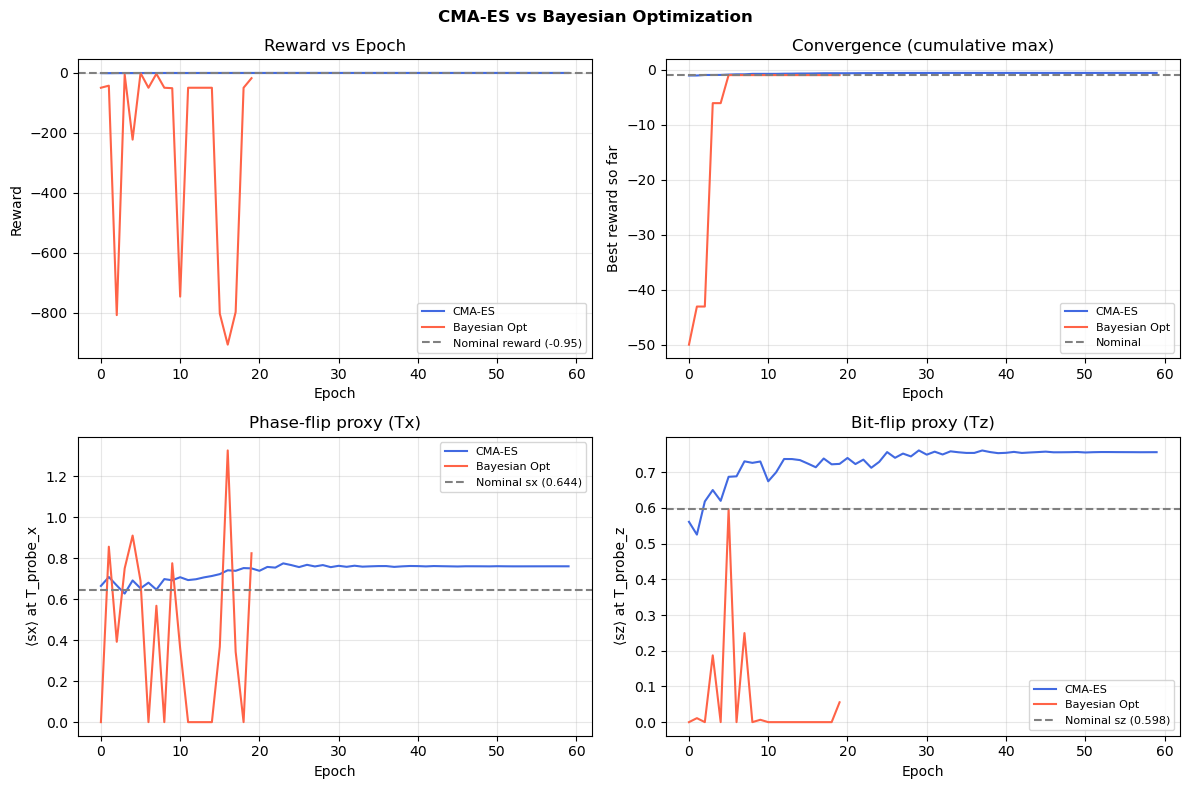

In [25]:
def plot_comparison(history_cma, history_bo, r_nom):
    epochs_cma = np.arange(len(history_cma['rewards']))
    epochs_bo  = np.arange(len(history_bo['rewards']))

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # ---- Reward vs epoch ----
    ax = axes[0, 0]
    ax.plot(epochs_cma, history_cma['rewards'], label='CMA-ES', color='royalblue')
    if 'rewards_std' in history_cma:
        ax.fill_between(epochs_cma,
            history_cma['rewards'] - history_cma['rewards_std'],
            history_cma['rewards'] + history_cma['rewards_std'],
            alpha=0.2, color='royalblue')
    ax.plot(epochs_bo, history_bo['rewards'], label='Bayesian Opt', color='tomato')
    ax.axhline(r_nom, linestyle='--', color='gray', label=f'Nominal reward ({r_nom:.2f})')
    ax.set(xlabel='Epoch', ylabel='Reward', title='Reward vs Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ---- Best reward so far (cumulative max) ----
    ax = axes[0, 1]
    ax.plot(epochs_cma, np.maximum.accumulate(history_cma['rewards']),
            label='CMA-ES', color='royalblue')
    ax.plot(epochs_bo, np.maximum.accumulate(history_bo['rewards']),
            label='Bayesian Opt', color='tomato')
    ax.axhline(r_nom, linestyle='--', color='gray', label='Nominal')
    ax.set(xlabel='Epoch', ylabel='Best reward so far', title='Convergence (cumulative max)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ---- sx proxy ----
    ax = axes[1, 0]
    ax.plot(epochs_cma, history_cma['sx'], label='CMA-ES', color='royalblue')
    ax.plot(epochs_bo,  history_bo['sx'],  label='Bayesian Opt', color='tomato')
    ax.axhline(sx_nom, linestyle='--', color='gray', label=f'Nominal sx ({sx_nom:.3f})')
    ax.set(xlabel='Epoch', ylabel='⟨sx⟩ at T_probe_x', title='Phase-flip proxy (Tx)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ---- sz proxy ----
    ax = axes[1, 1]
    ax.plot(epochs_cma, history_cma['sz'], label='CMA-ES', color='royalblue')
    ax.plot(epochs_bo,  history_bo['sz'],  label='Bayesian Opt', color='tomato')
    ax.axhline(sz_nom, linestyle='--', color='gray', label=f'Nominal sz ({sz_nom:.3f})')
    ax.set(xlabel='Epoch', ylabel='⟨sz⟩ at T_probe_z', title='Bit-flip proxy (Tz)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.suptitle('CMA-ES vs Bayesian Optimization', fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_comparison(history_cma, history_bo, r_nom)

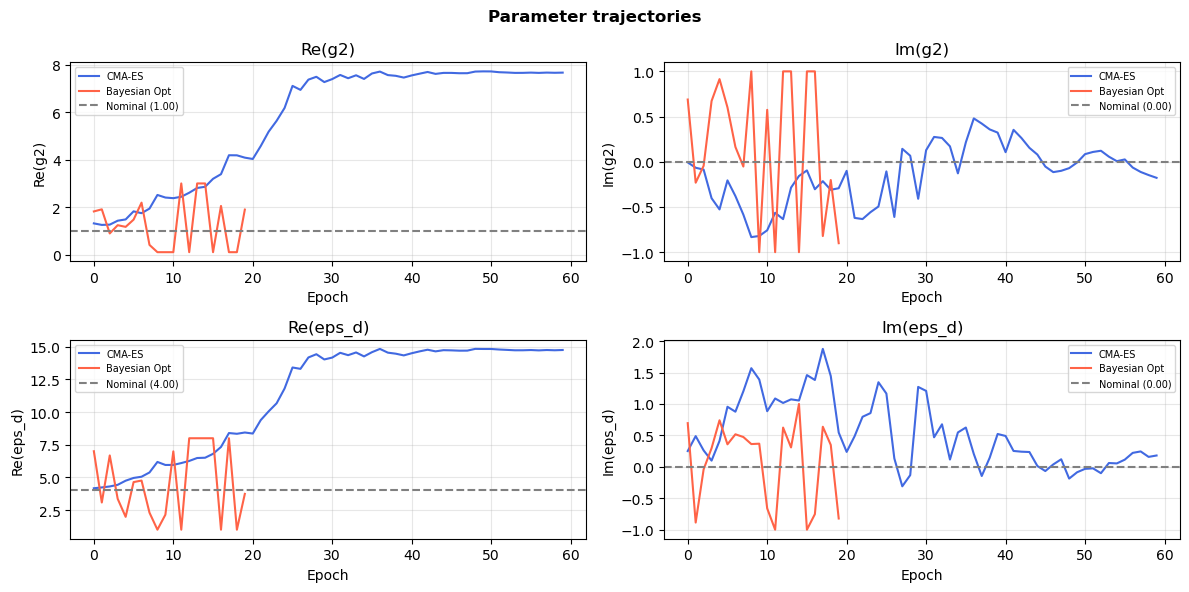

In [26]:
def plot_parameter_convergence(history_cma, history_bo):
    """Plot parameter trajectories for both optimizers."""
    labels   = ['Re(g2)', 'Im(g2)', 'Re(eps_d)', 'Im(eps_d)']
    nominals = [
        float(g_2_nom.real), float(g_2_nom.imag),
        float(eps_d_nom.real), float(eps_d_nom.imag)
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 6))

    params_cma = np.array(history_cma['params'])   # (epochs, 4)
    params_bo  = np.array(history_bo['params'])    # (epochs, 4)

    epochs_cma = np.arange(len(params_cma))
    epochs_bo  = np.arange(len(params_bo))

    for i, (ax, label, nom) in enumerate(zip(axes.flat, labels, nominals)):
        ax.plot(epochs_cma, params_cma[:, i], label='CMA-ES', color='royalblue')
        ax.plot(epochs_bo,  params_bo[:, i],  label='Bayesian Opt', color='tomato')
        ax.axhline(nom, linestyle='--', color='gray', label=f'Nominal ({nom:.2f})')
        ax.set(xlabel='Epoch', ylabel=label, title=label)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Parameter trajectories', fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_parameter_convergence(history_cma, history_bo)

## Step 5: Verify best parameters with full fit

After optimization, run full exponential fits at the best found parameters
to verify that the proxy reward genuinely tracked the true lifetimes.

In [55]:
def verify_params(params, label=''):
    """
    Run full exponential fits at given parameters.
    Used to verify that proxy-based optimization actually improved true lifetimes.
    """
    g2    = complex(params[0], params[1])
    eps_d = complex(params[2], params[3])

    print(f"\nVerifying {label}: g2={g2:.3f}, eps_d={eps_d:.3f}")

    res_x = measure_lifetime('+x', 8.0, eps_d, g2, ntimes=100)
    res_z = measure_lifetime('+z', 300.0, eps_d, g2, ntimes=100)

    ts_x = np.linspace(0, 8.0, 100)
    ts_z = np.linspace(0, 300.0, 100)

    fit_x = robust_exp_fit(ts_x, res_x.expects[0].real)
    fit_z = robust_exp_fit(ts_z, res_z.expects[1].real)

    Tx  = fit_x['tau']
    Tz  = fit_z['tau']
    eta = Tz / Tx

    print(f"  Tx  = {Tx:.4f} µs  (baseline: {Tx_baseline:.4f})")
    print(f"  Tz  = {Tz:.2f} µs  (baseline: {Tz_baseline:.2f})")
    print(f"  η   = {eta:.1f}  (baseline: {eta_baseline:.1f})")

    return Tx, Tz, eta


# Nominal
Tx_n, Tz_n, eta_n = verify_params(
    [g_2_nom.real, g_2_nom.imag, eps_d_nom.real, eps_d_nom.imag],
    label='Nominal'
)

# Best CMA-ES
Tx_cma, Tz_cma, eta_cma = verify_params(
    history_cma['best_params'],
    label='CMA-ES best'
)

# Best Bayesian Opt
Tx_bo, Tz_bo, eta_bo = verify_params(
    history_bo['best_params'],
    label='Bayesian Opt best'
)


Verifying Nominal: g2=1.000+0.000j, eps_d=4.000+0.000j
  Tx  = 0.1700 µs  (baseline: 0.1700)
  Tz  = 57.19 µs  (baseline: 57.19)
  η   = 336.4  (baseline: 336.4)

Verifying CMA-ES best: g2=7.675-0.178j, eps_d=14.755+0.180j
  Tx  = 0.2667 µs  (baseline: 0.1700)
  Tz  = 102.58 µs  (baseline: 57.19)
  η   = 384.7  (baseline: 336.4)

Verifying Bayesian Opt best: g2=1.473+0.602j, eps_d=4.643+0.358j
  Tx  = 0.2057 µs  (baseline: 0.1700)
  Tz  = 70.45 µs  (baseline: 57.19)
  η   = 342.6  (baseline: 336.4)


In [56]:
# ---- Summary table ----
print("\n" + "=" * 55)
print(f"{'':20s} {'Tx [µs]':>10s} {'Tz [µs]':>10s} {'η':>10s}")
print("-" * 55)
print(f"{'Nominal':20s} {Tx_n:>10.4f} {Tz_n:>10.2f} {eta_n:>10.1f}")
print(f"{'CMA-ES best':20s} {Tx_cma:>10.4f} {Tz_cma:>10.2f} {eta_cma:>10.1f}")
print(f"{'Bayesian Opt best':20s} {Tx_bo:>10.4f} {Tz_bo:>10.2f} {eta_bo:>10.1f}")
print("=" * 55)


                        Tx [µs]    Tz [µs]          η
-------------------------------------------------------
Nominal                  0.1700      57.19      336.4
CMA-ES best              0.2667     102.58      384.7
Bayesian Opt best        0.2057      70.45      342.6


|          |   0.3% ◆ elapsed 2.08ms ◆ remaining 0.00ms

|██████████| 100.0% ◆ elapsed 36.56ms ◆ remaining 0.00ms
100%|██████████| 50/50 [00:01<00:00, 36.11it/s]


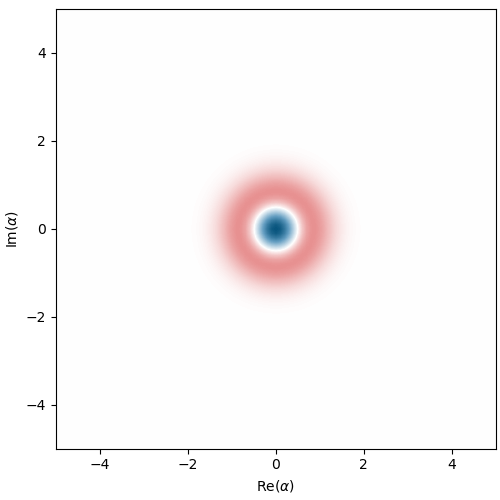

In [44]:
kaa = 0.0
a, b = make_operators()
# Nominal
H_nom = (jnp.conj(g_2_nom) * a @ a @ b.dag() + g_2_nom * a.dag() @ a.dag() @ b 
         - eps_d_nom * b.dag() - jnp.conj(eps_d_nom) * b)
res_nom = dq.mesolve(H_nom, [jnp.sqrt(kb)*b, jnp.sqrt(ka)*a], 
                     dq.tensor(dq.fock(na, 1), dq.fock(nb, 0)), jnp.linspace(0, 3, 100))

dq.plot.wigner_gif(dq.ptrace(res_nom.states, 0))

|▍         |   4.6% ◆ elapsed 8.65ms ◆ remaining 0.00ms

|██████████| 100.0% ◆ elapsed 185.89ms ◆ remaining 0.00ms 
100%|██████████| 50/50 [00:01<00:00, 36.62it/s]


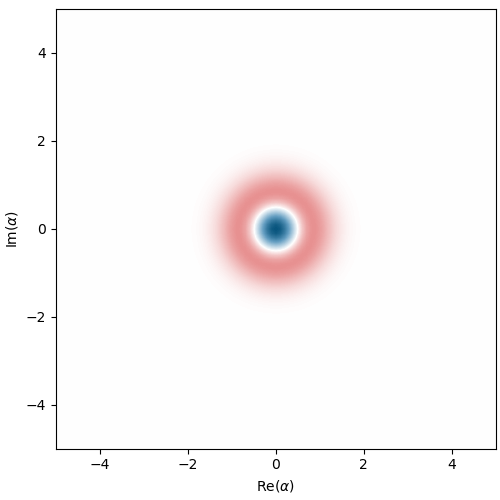

In [45]:
# CMA-ES
g2_cma = complex(history_cma['best_params'][0], history_cma['best_params'][1])
epsd_cma = complex(history_cma['best_params'][2], history_cma['best_params'][3])

H_cma = (jnp.conj(g2_cma) * a @ a @ b.dag() + g2_cma * a.dag() @ a.dag() @ b 
         - epsd_cma * b.dag() - jnp.conj(epsd_cma) * b)
res_cma = dq.mesolve(H_cma, [jnp.sqrt(kb)*b, jnp.sqrt(ka)*a], 
                     dq.tensor(dq.fock(na, 1), dq.fock(nb, 0)), jnp.linspace(0, 3, 100))

dq.plot.wigner_gif(dq.ptrace(res_cma.states, 0))

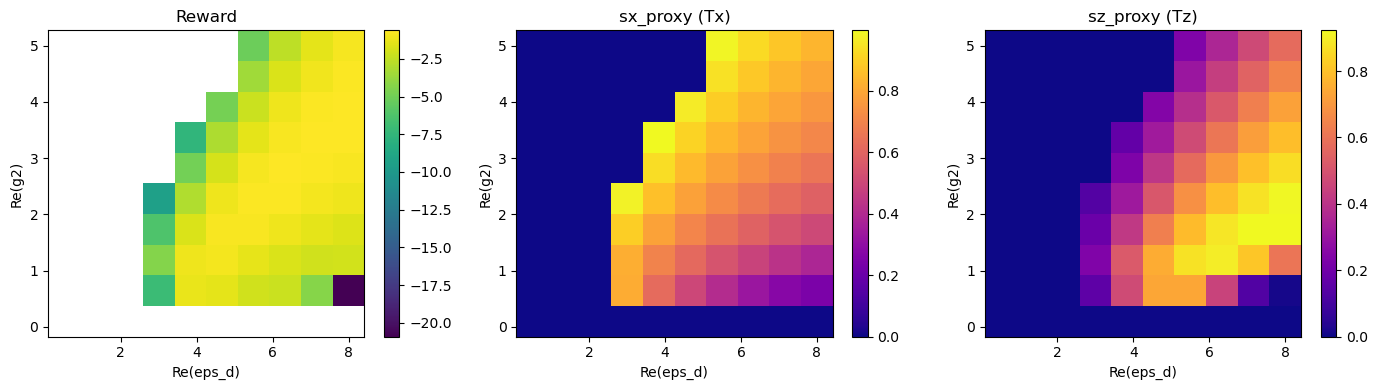

In [46]:
re_g2_vals   = jnp.linspace(0.1, 5.0, 10)
re_epsd_vals = jnp.linspace(0.5, 8.0, 10)

reward_map = jnp.zeros((10, 10))
Tx_map     = jnp.zeros((10, 10))
sz_map     = jnp.zeros((10, 10))

for i, g2v in enumerate(re_g2_vals):
    for j, epdv in enumerate(re_epsd_vals):
        try:
            r, sx, sz, _ = reward(g2v + 0j, epdv + 0j)
            reward_map = reward_map.at[i,j].set(r)
            Tx_map     = Tx_map.at[i,j].set(sx)
            sz_map     = sz_map.at[i,j].set(sz)
        except:
            reward_map = reward_map.at[i,j].set(float('nan'))

# Plot heatmaps
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].pcolormesh(re_epsd_vals, re_g2_vals, reward_map, cmap='viridis')
axes[0].set_xlabel("Re(eps_d)")
axes[0].set_ylabel("Re(g2)")
axes[0].set_title("Reward")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(re_epsd_vals, re_g2_vals, Tx_map, cmap='plasma')
axes[1].set_xlabel("Re(eps_d)")
axes[1].set_ylabel("Re(g2)")
axes[1].set_title("sx_proxy (Tx)")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(re_epsd_vals, re_g2_vals, sz_map, cmap='plasma')
axes[2].set_xlabel("Re(eps_d)")
axes[2].set_ylabel("Re(g2)")
axes[2].set_title("sz_proxy (Tz)")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [48]:
for i, g2v in enumerate(re_g2_vals):
    for j, epdv in enumerate(re_epsd_vals):
        try:
            r, sx, sz, _ = reward(g2v + 0j, epdv + 0j)
            if sx > 1.0:
                print(f"g2={g2v:.2f}, eps_d={epdv:.2f} → sx={sx:.4f}, sz={sz:.4f}")
        except:
            pass

In [53]:
def check_photon_number(g2, eps_d):
    a, b = make_operators()
    res = measure_lifetime("+x", 1.0, eps_d=eps_d, g_2=g2, ntimes=5)
    # photon number operator in joint Hilbert space
    n_op = dq.tensor(dq.number(na), dq.eye(nb))
    n_avg = dq.expect(n_op, res.states[-1]).real
    alpha_est = jnp.sqrt(2 / (4*jnp.abs(g2)**2/kb) * (2*g2*eps_d/kb - ka/4))
    print(f"g2={g2:.2f}, eps_d={eps_d:.2f} → ⟨n⟩={float(n_avg):.2f}, alpha_est={float(alpha_est.real):.2f}")

# Check problematic cases

for i in range(5, 8):
    for j in range(2, 5):
        check_photon_number(j, i)


g2=2.00, eps_d=5.00 → ⟨n⟩=2.13, alpha_est=1.48
g2=3.00, eps_d=5.00 → ⟨n⟩=1.52, alpha_est=1.24
g2=4.00, eps_d=5.00 → ⟨n⟩=1.19, alpha_est=1.08
g2=2.00, eps_d=6.00 → ⟨n⟩=2.62, alpha_est=1.64
g2=3.00, eps_d=6.00 → ⟨n⟩=1.83, alpha_est=1.36
g2=4.00, eps_d=6.00 → ⟨n⟩=1.43, alpha_est=1.19
g2=2.00, eps_d=7.00 → ⟨n⟩=3.11, alpha_est=1.79
g2=3.00, eps_d=7.00 → ⟨n⟩=2.16, alpha_est=1.48
g2=4.00, eps_d=7.00 → ⟨n⟩=1.67, alpha_est=1.29


|██████████| 100.0% ◆ elapsed 62.50ms ◆ remaining 0.00ms
100%|██████████| 50/50 [00:01<00:00, 38.95it/s]


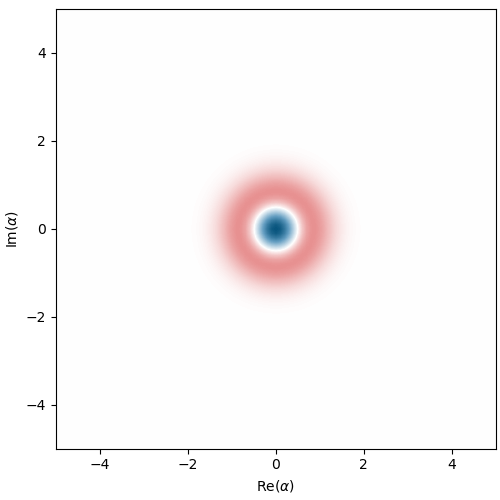

In [41]:
# Bayesian Opt
g2_bo = complex(history_bo['best_params'][0], history_bo['best_params'][1])
epsd_bo = complex(history_bo['best_params'][2], history_bo['best_params'][3])

H_bo = (jnp.conj(g2_bo) * a @ a @ b.dag() + g2_bo * a.dag() @ a.dag() @ b 
        - epsd_bo * b.dag() - jnp.conj(epsd_bo) * b)
res_bo = dq.mesolve(H_bo, [jnp.sqrt(kb)*b, jnp.sqrt(ka)*a], 
                    dq.tensor(dq.fock(na, 1), dq.fock(nb, 0)), jnp.linspace(0, 3, 100))

dq.plot.wigner_gif(dq.ptrace(res_bo.states, 0))

## Next steps: Drift (Part 3)

Once you are satisfied with the reward function and optimizer, the natural
next step is to introduce epoch-dependent hardware drift and verify that
the optimizer can track the moving optimum.

A minimal starting drift model:

```python
# Sinusoidal amplitude drift on g2
g2_drift = lambda epoch: g_2_nom * (1 + 0.15 * jnp.sin(2 * jnp.pi * epoch / 50))

# In the optimization loop, pass the drifted parameter to measure_lifetime
# but keep the optimizer knobs as corrections around the drifted value
```

The key design question: do you give the optimizer the true drift value
(oracle) or must it discover it purely from reward signals?
The latter is more realistic and more interesting.